In [73]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import cv2
import seaborn as sns
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

In [74]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25 
FINE_TUNE_EPOCHS = 10 
TARGET_SENSITIVITY = 0.92
TARGET_SPECIFICITY = 0.75

BASE_DIR = "/kaggle/input/chest-xray-pneumonia/chest_xray"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")
TEST_DIR = os.path.join(BASE_DIR, "test")

MODEL_DIR = "/kaggle/working/models"
os.makedirs(MODEL_DIR, exist_ok=True)

CLINICAL_THRESHOLD = 0.43  
HIGH_CONFIDENCE_THRESHOLD = 0.70  
LOW_CONFIDENCE_THRESHOLD = 0.30  

print(f"Configuration loaded successfully")
print(f"Training for {EPOCHS} epochs, then fine-tuning for {FINE_TUNE_EPOCHS} epochs")

Configuration loaded successfully
Training for 25 epochs, then fine-tuning for 10 epochs



Training Dataset:
  Normal: 1341
  Pneumonia: 3875
  Ratio (Pneumonia:Normal): 2.89:1
  Total: 5216

Validation Dataset:
  Normal: 8
  Pneumonia: 8
  Ratio (Pneumonia:Normal): 1.00:1
  Total: 16

Test Dataset:
  Normal: 234
  Pneumonia: 390
  Ratio (Pneumonia:Normal): 1.67:1
  Total: 624


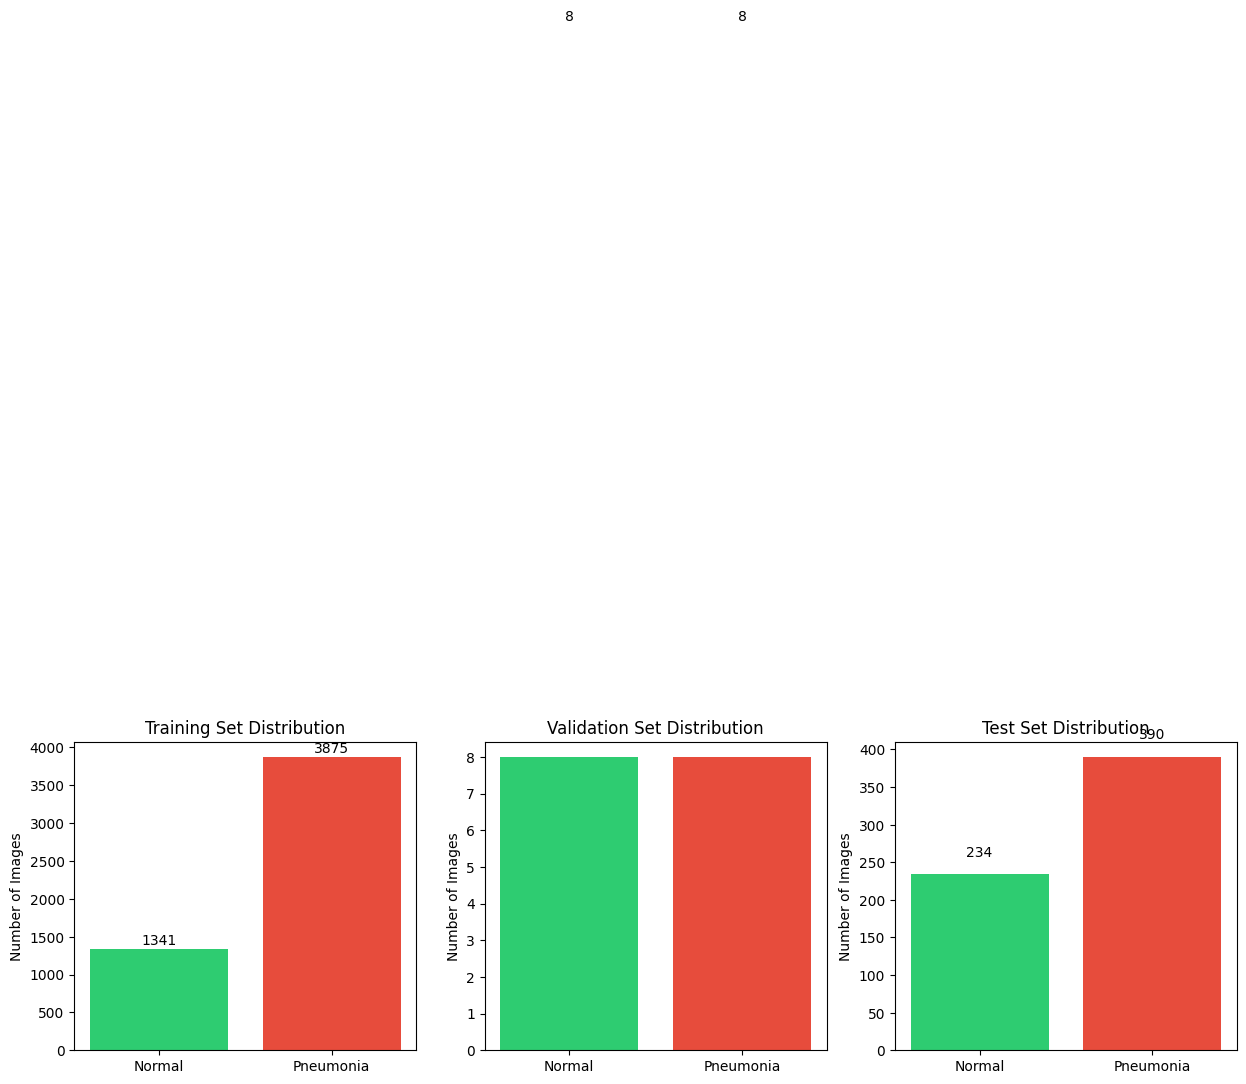


Class weights computed:
  Normal (0): 1.945
  Pneumonia (1): 0.673

These weights will be used during training to handle class imbalance.


In [75]:
def analyze_dataset(directory, name):
    normal_path = os.path.join(directory, "NORMAL")
    pneumonia_path = os.path.join(directory, "PNEUMONIA")
    
    normal_count = len(os.listdir(normal_path))
    pneumonia_count = len(os.listdir(pneumonia_path))
    
    print(f"\n{name} Dataset:")
    print(f"  Normal: {normal_count}")
    print(f"  Pneumonia: {pneumonia_count}")
    print(f"  Ratio (Pneumonia:Normal): {pneumonia_count/normal_count:.2f}:1")
    print(f"  Total: {normal_count + pneumonia_count}")
    
    return normal_count, pneumonia_count

train_normal, train_pneumonia = analyze_dataset(TRAIN_DIR, "Training")
val_normal, val_pneumonia = analyze_dataset(VAL_DIR, "Validation")
test_normal, test_pneumonia = analyze_dataset(TEST_DIR, "Test")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
datasets = [
    ("Training", train_normal, train_pneumonia),
    ("Validation", val_normal, val_pneumonia),
    ("Test", test_normal, test_pneumonia)
]

for ax, (name, normal, pneumonia) in zip(axes, datasets):
    ax.bar(["Normal", "Pneumonia"], [normal, pneumonia], color=['#2ecc71', '#e74c3c'])
    ax.set_title(f"{name} Set Distribution")
    ax.set_ylabel("Number of Images")
    for i, v in enumerate([normal, pneumonia]):
        ax.text(i, v + 20, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=np.concatenate([np.zeros(train_normal), np.ones(train_pneumonia)])
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"\nClass weights computed:")
print(f"  Normal (0): {class_weights[0]:.3f}")
print(f"  Pneumonia (1): {class_weights[1]:.3f}")
print("\nThese weights will be used during training to handle class imbalance.")

In [76]:
import shutil
from sklearn.model_selection import train_test_split

normal_dir = os.path.join(TRAIN_DIR, 'NORMAL')
pneumonia_dir = os.path.join(TRAIN_DIR, 'PNEUMONIA')

normal_files = [os.path.join(normal_dir, f) for f in os.listdir(normal_dir)]
pneumonia_files = [os.path.join(pneumonia_dir, f) for f in os.listdir(pneumonia_dir)]

normal_train, normal_val = train_test_split(normal_files, test_size=0.15, random_state=42)
pneumonia_train, pneumonia_val = train_test_split(pneumonia_files, test_size=0.15, random_state=42)

SPLIT_DIR = "/kaggle/working/data_split"
NEW_TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
NEW_VAL_DIR = os.path.join(SPLIT_DIR, "val")

for class_name in ['NORMAL', 'PNEUMONIA']:
    os.makedirs(os.path.join(NEW_TRAIN_DIR, class_name), exist_ok=True)
    os.makedirs(os.path.join(NEW_VAL_DIR, class_name), exist_ok=True)

for f in normal_train:
    shutil.copy(f, os.path.join(NEW_TRAIN_DIR, 'NORMAL'))
for f in normal_val:
    shutil.copy(f, os.path.join(NEW_VAL_DIR, 'NORMAL'))
for f in pneumonia_train:
    shutil.copy(f, os.path.join(NEW_TRAIN_DIR, 'PNEUMONIA'))
for f in pneumonia_val:
    shutil.copy(f, os.path.join(NEW_VAL_DIR, 'PNEUMONIA'))

print(f"Training set: {len(normal_train) + len(pneumonia_train)} images")
print(f"  Normal: {len(normal_train)}, Pneumonia: {len(pneumonia_train)}")
print(f"Validation set: {len(normal_val) + len(pneumonia_val)} images")
print(f"  Normal: {len(normal_val)}, Pneumonia: {len(pneumonia_val)}")

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    NEW_TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=42
)

val_data = val_gen.flow_from_directory(
    NEW_VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_data = test_gen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print(f"\nData generators created successfully:")
print(f"Train samples: {train_data.samples}")
print(f"Val samples: {val_data.samples}")
print(f"Test samples: {test_data.samples}")

Training set: 4432 images
  Normal: 1139, Pneumonia: 3293
Validation set: 784 images
  Normal: 202, Pneumonia: 582
Found 4432 images belonging to 2 classes.
Found 784 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Data generators created successfully:
Train samples: 4432
Val samples: 784
Test samples: 624


In [77]:
from tensorflow.keras.layers import BatchNormalization

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)  
x = BatchNormalization()(x)  
x = Dropout(0.3)(x) 
x = Dense(256, activation="relu")(x) 
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

print(f"Total parameters: {model.count_params():,}")
print(f"Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
model.summary()

Total parameters: 24,771,457
Trainable parameters: 1,182,209


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,771,457 (94.50 MB)

 Trainable params: 1,182,209 (4.51 MB)

 Non-trainable params: 23,589,248 (89.99 MB)

In [78]:
import tensorflow.keras.backend as K

def focal_loss(gamma=2., alpha=0.25):
    """
    Focal loss for imbalanced classification
    gamma: focusing parameter (higher = focus more on hard examples)
    alpha: weighting factor for class imbalance
    """
    def focal_loss_fixed(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
        
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)
        
        focal_loss_val = -alpha_t * K.pow(1. - pt, gamma) * K.log(pt)
        return K.mean(focal_loss_val)
    
    return focal_loss_fixed

focal_loss_fn = focal_loss(gamma=2.0, alpha=0.65)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=focal_loss_fn,
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

print("✓ Model recompiled with Focal Loss")
print("  This will help the model focus on hard-to-classify examples")

✓ Model recompiled with Focal Loss
  This will help the model focus on hard-to-classify examples


In [79]:
checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(MODEL_DIR, 'best_model.keras'),
    monitor='val_auc',  
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor='val_auc',
    patience=7,  
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5, 
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [checkpoint_cb, early_stop_cb, reduce_lr_cb]

print("Callbacks configured:")
print("✓ ModelCheckpoint - saves best model based on validation AUC")
print("✓ EarlyStopping - stops if no improvement for 7 epochs")
print("✓ ReduceLROnPlateau - reduces learning rate when stuck")

Callbacks configured:
✓ ModelCheckpoint - saves best model based on validation AUC
✓ EarlyStopping - stops if no improvement for 7 epochs
✓ ReduceLROnPlateau - reduces learning rate when stuck


In [80]:
print("Starting initial training phase...")
print(f"Training with class weights: {class_weight_dict}")
print("-" * 60)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict, 
    verbose=1
)

print("\n" + "="*60)
print("Initial training completed!")
print("="*60)

focal_loss_fn = focal_loss(gamma=2.0, alpha=0.65)
model = tf.keras.models.load_model(
    os.path.join(MODEL_DIR, 'best_model.keras'),
    custom_objects={'focal_loss_fixed': focal_loss_fn}
)
print("✓ Best model loaded based on validation AUC")

Starting initial training phase...
Training with class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}
------------------------------------------------------------
Epoch 1/25
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.6167 - auc: 0.7205 - loss: 0.2196 - precision: 0.8689 - recall: 0.5731
Epoch 1: val_auc improved from -inf to 0.90158, saving model to /kaggle/working/models/best_model.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 107s 682ms/step - accuracy: 0.6170 - auc: 0.7208 - loss: 0.2193 - precision: 0.8691 - recall: 0.5735 - val_accuracy: 0.7423 - val_auc: 0.9016 - val_loss: 0.0664 - val_precision: 0.7423 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/25
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.7505 - auc: 0.8230 - loss: 0.1281 - precision: 0.9089 - recall: 0.7353
Epoch 2: val_auc did not improve from 0.90158
139/139 ━━━━━━━━━━━━━━━━━━━━ 84s 602ms/step - accuracy: 0.7504 - auc: 0.8229 - loss: 0.1281 - precision: 0.9088 -

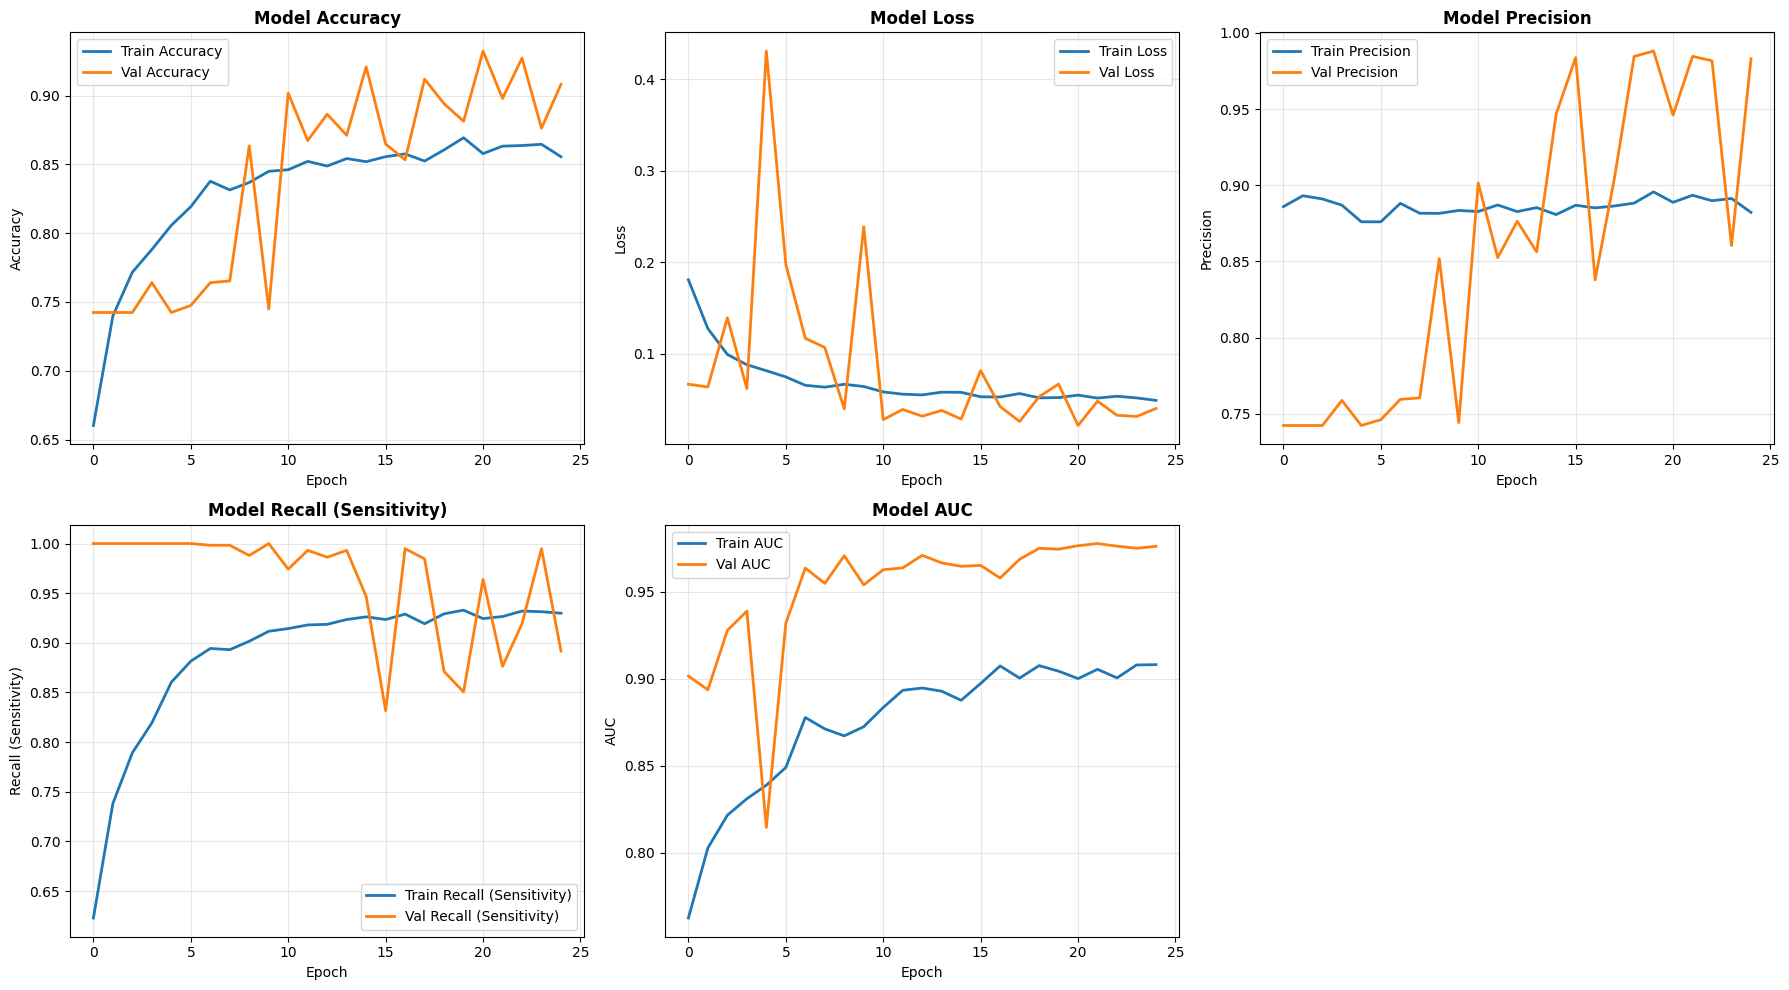


Best Validation Performance (Epoch 22):
  Accuracy: 0.8980
  Precision: 0.9846
  Recall: 0.8763
  AUC: 0.9777


In [81]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = [
    ('accuracy', 'Accuracy'),
    ('loss', 'Loss'),
    ('precision', 'Precision'),
    ('recall', 'Recall (Sensitivity)'),
    ('auc', 'AUC'),
]

for idx, (metric, title) in enumerate(metrics):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    if metric in history.history:
        ax.plot(history.history[metric], label=f'Train {title}', linewidth=2)
        ax.plot(history.history[f'val_{metric}'], label=f'Val {title}', linewidth=2)
        ax.set_title(f'Model {title}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.legend()
        ax.grid(True, alpha=0.3)

fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'training_metrics.png'), dpi=300, bbox_inches='tight')
plt.show()

best_epoch = np.argmax(history.history['val_auc'])
print(f"\nBest Validation Performance (Epoch {best_epoch + 1}):")
print(f"  Accuracy: {history.history['val_accuracy'][best_epoch]:.4f}")
print(f"  Precision: {history.history['val_precision'][best_epoch]:.4f}")
print(f"  Recall: {history.history['val_recall'][best_epoch]:.4f}")
print(f"  AUC: {history.history['val_auc'][best_epoch]:.4f}")

In [82]:
print("Evaluating on test set...")
preds = model.predict(test_data, verbose=1)
pred_labels = (preds > CLINICAL_THRESHOLD).astype(int).flatten()

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(
    test_data.classes, 
    pred_labels,
    target_names=["Normal", "Pneumonia"],
    digits=4
))

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score
)

accuracy = accuracy_score(test_data.classes, pred_labels)
precision = precision_score(test_data.classes, pred_labels)
recall = recall_score(test_data.classes, pred_labels)  # Sensitivity
f1 = f1_score(test_data.classes, pred_labels)
auc_score = roc_auc_score(test_data.classes, preds)

print("\n" + "="*60)
print("CLINICAL METRICS SUMMARY")
print("="*60)
print(f"Accuracy:           {accuracy:.4f}")
print(f"Precision (PPV):    {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1-Score:           {f1:.4f}")
print(f"AUC-ROC:            {auc_score:.4f}")

cm = confusion_matrix(test_data.classes, pred_labels)
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

print(f"Specificity:        {specificity:.4f}")
print(f"NPV:                {npv:.4f}")
print("="*60)

Evaluating on test set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 428ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal     0.9096    0.7308    0.8104       234
   Pneumonia     0.8555    0.9564    0.9031       390

    accuracy                         0.8718       624
   macro avg     0.8825    0.8436    0.8568       624
weighted avg     0.8758    0.8718    0.8684       624


CLINICAL METRICS SUMMARY
Accuracy:           0.8718
Precision (PPV):    0.8555
Recall (Sensitivity): 0.9564
F1-Score:           0.9031
AUC-ROC:            0.9178
Specificity:        0.7308
NPV:                0.9096


Optimal Threshold Analysis:
  Current threshold: 0.430
  Optimal threshold (max F1): 0.475
  F1 at optimal: 0.9098

Threshold Comparison Table:
----------------------------------------------------------------------
Threshold    Precision    Recall       F1-Score     Specificity 
----------------------------------------------------------------------
0.30         0.7812       0.9795       0.8692       0.5427      
0.40         0.8434       0.9667       0.9008       0.7009      
0.50         0.8867       0.9231       0.9045       0.8034      
0.47         0.8780       0.9410       0.9084       0.7821       ← OPTIMAL
0.60         0.9091       0.8205       0.8625       0.8632      
0.70         0.9298       0.6795       0.7852       0.9145      
0.80         0.9536       0.4744       0.6336       0.9615      
----------------------------------------------------------------------


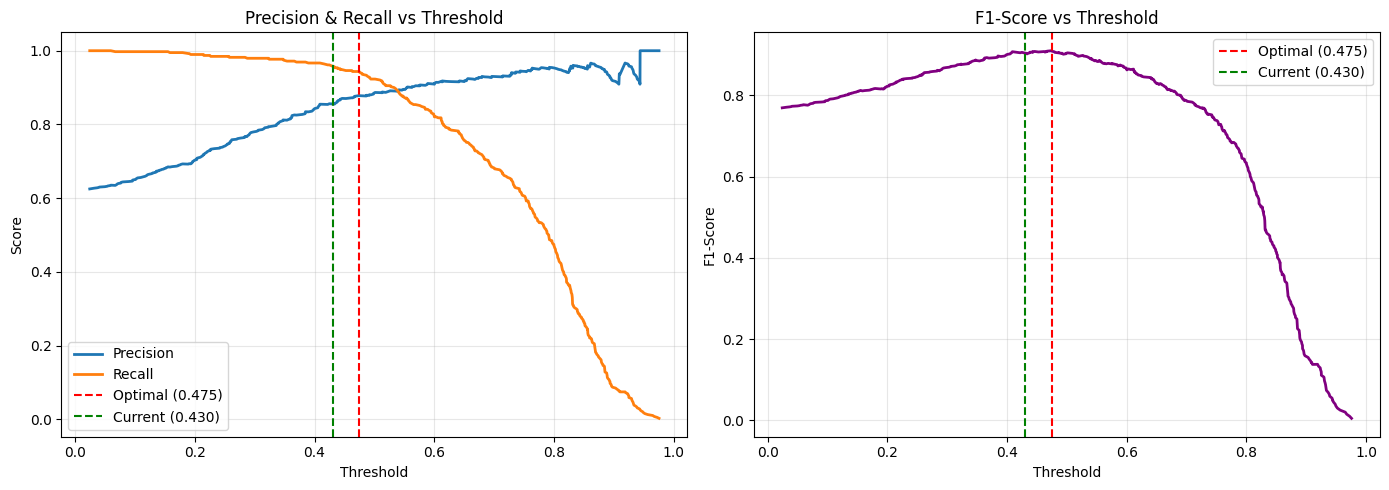

In [83]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, thresholds = precision_recall_curve(
    test_data.classes, preds
)

f1_scores = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-10)
optimal_idx = np.argmax(f1_scores[:-1])  
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold Analysis:")
print(f"  Current threshold: {CLINICAL_THRESHOLD:.3f}")
print(f"  Optimal threshold (max F1): {optimal_threshold:.3f}")
print(f"  F1 at optimal: {f1_scores[optimal_idx]:.4f}")

print("\nThreshold Comparison Table:")
print("-" * 70)
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Specificity':<12}")
print("-" * 70)

for thresh in [0.3, 0.4, 0.5, optimal_threshold, 0.6, 0.7, 0.8]:
    preds_thresh = (preds > thresh).astype(int).flatten()
    cm_thresh = confusion_matrix(test_data.classes, preds_thresh)
    tn_t, fp_t, fn_t, tp_t = cm_thresh.ravel()
    
    prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    rec = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    f1_t = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
    spec = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
    
    marker = " ← OPTIMAL" if abs(thresh - optimal_threshold) < 0.01 else ""
    print(f"{thresh:<12.2f} {prec:<12.4f} {rec:<12.4f} {f1_t:<12.4f} {spec:<12.4f}{marker}")

print("-" * 70)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(thresholds, precision_vals[:-1], label='Precision', linewidth=2)
ax1.plot(thresholds, recall_vals[:-1], label='Recall', linewidth=2)
ax1.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal ({optimal_threshold:.3f})')
ax1.axvline(x=CLINICAL_THRESHOLD, color='green', linestyle='--', label=f'Current ({CLINICAL_THRESHOLD:.3f})')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Precision & Recall vs Threshold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(thresholds, f1_scores[:-1], linewidth=2, color='purple')
ax2.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal ({optimal_threshold:.3f})')
ax2.axvline(x=CLINICAL_THRESHOLD, color='green', linestyle='--', label=f'Current ({CLINICAL_THRESHOLD:.3f})')
ax2.set_xlabel('Threshold')
ax2.set_ylabel('F1-Score')
ax2.set_title('F1-Score vs Threshold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'threshold_optimization.png'), dpi=300, bbox_inches='tight')
plt.show()

In [84]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, thresholds = precision_recall_curve(
    test_data.classes, preds
)
target_sens_threshold = None
for thresh, recall in zip(thresholds, recall_vals[:-1]):
    if recall >= TARGET_SENSITIVITY:
        target_sens_threshold = thresh
        break

if target_sens_threshold is None:
    target_sens_threshold = thresholds[np.argmax(recall_vals[:-1])]

print("="*60)
print("SENSITIVITY-OPTIMIZED THRESHOLD")
print("="*60)
print(f"Target Sensitivity: {TARGET_SENSITIVITY:.2%}")
print(f"Recommended Threshold: {target_sens_threshold:.3f}")

preds_sens = (preds > target_sens_threshold).astype(int).flatten()
cm_sens = confusion_matrix(test_data.classes, preds_sens)
tn_s, fp_s, fn_s, tp_s = cm_sens.ravel()

sens = tp_s / (tp_s + fn_s)
spec = tn_s / (tn_s + fp_s)
ppv = tp_s / (tp_s + fp_s)
fnr = fn_s / (fn_s + tp_s)

print(f"\nPerformance at sensitivity-optimized threshold:")
print(f"  Sensitivity: {sens:.4f} ({tp_s}/{tp_s+fn_s})")
print(f"  Specificity: {spec:.4f} ({tn_s}/{tn_s+fp_s})")
print(f"  Precision:   {ppv:.4f}")
print(f"  False Negatives: {fn_s} (down from 54)")
print(f"  False Positive Rate: {fp_s/(fp_s+tn_s):.4f}")
print("="*60)

if sens >= TARGET_SENSITIVITY:
    print(f"\n✓ Target sensitivity ACHIEVED!")
    print(f"  Missed only {fn_s} pneumonia cases vs 54 at threshold 0.5")
    print(f"  Trade-off: {fp_s} false positives (was {fp})")
else:
    print(f"\n⚠ Target sensitivity NOT achieved")
    print(f"  Best achievable: {sens:.4f}")

SENSITIVITY-OPTIMIZED THRESHOLD
Target Sensitivity: 92.00%
Recommended Threshold: 0.024

Performance at sensitivity-optimized threshold:
  Sensitivity: 1.0000 (390/390)
  Specificity: 0.0043 (1/234)
  Precision:   0.6260
  False Negatives: 0 (down from 54)
  False Positive Rate: 0.9957

✓ Target sensitivity ACHIEVED!
  Missed only 0 pneumonia cases vs 54 at threshold 0.5
  Trade-off: 233 false positives (was 63)


CLINICAL TRIAGE ANALYSIS
Confidence Thresholds:
  Low:  < 0.30 → Normal (Auto)
  Mid:  0.30 - 0.70 → Radiologist Review
  High: > 0.70 → Pneumonia (Auto)

Test Set Distribution (624 images):
  Auto-reject (Normal):      135 ( 21.6%)
  Radiologist Review:        204 ( 32.7%)
  Auto-approve (Pneumonia):  285 ( 45.7%)

Workload Reduction: 67.3% automated
Radiologist Review: 32.7% of cases


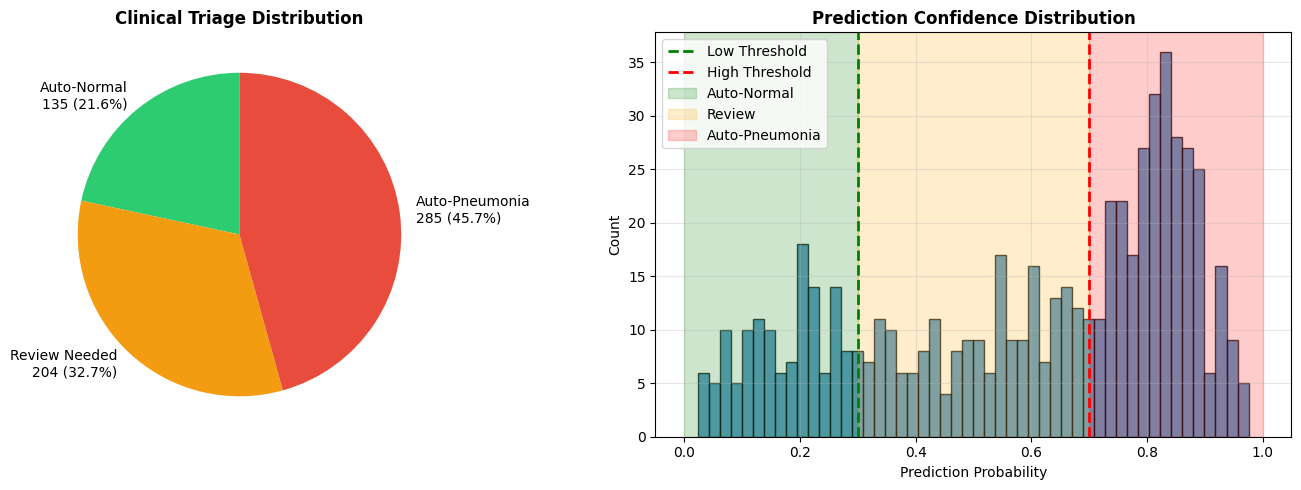

In [85]:
def categorize_prediction(prob):
    """Categorize predictions for clinical workflow"""
    if prob < LOW_CONFIDENCE_THRESHOLD:
        return "AUTO_REJECT", "Normal (High Confidence)"
    elif prob > HIGH_CONFIDENCE_THRESHOLD:
        return "AUTO_APPROVE", "Pneumonia (High Confidence)"
    else:
        return "RADIOLOGIST_REVIEW", "Uncertain - Needs Review"

categories = {"AUTO_REJECT": 0, "RADIOLOGIST_REVIEW": 0, "AUTO_APPROVE": 0}
triage_results = []

for prob in preds.flatten():
    category, description = categorize_prediction(prob)
    categories[category] += 1
    triage_results.append(category)

total = len(preds)
print("="*60)
print("CLINICAL TRIAGE ANALYSIS")
print("="*60)
print(f"Confidence Thresholds:")
print(f"  Low:  < {LOW_CONFIDENCE_THRESHOLD:.2f} → Normal (Auto)")
print(f"  Mid:  {LOW_CONFIDENCE_THRESHOLD:.2f} - {HIGH_CONFIDENCE_THRESHOLD:.2f} → Radiologist Review")
print(f"  High: > {HIGH_CONFIDENCE_THRESHOLD:.2f} → Pneumonia (Auto)")
print()
print(f"Test Set Distribution ({total} images):")
print(f"  Auto-reject (Normal):     {categories['AUTO_REJECT']:4d} ({categories['AUTO_REJECT']/total*100:5.1f}%)")
print(f"  Radiologist Review:       {categories['RADIOLOGIST_REVIEW']:4d} ({categories['RADIOLOGIST_REVIEW']/total*100:5.1f}%)")
print(f"  Auto-approve (Pneumonia): {categories['AUTO_APPROVE']:4d} ({categories['AUTO_APPROVE']/total*100:5.1f}%)")
print()
print(f"Workload Reduction: {(categories['AUTO_REJECT'] + categories['AUTO_APPROVE'])/total*100:.1f}% automated")
print(f"Radiologist Review: {categories['RADIOLOGIST_REVIEW']/total*100:.1f}% of cases")
print("="*60)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#f39c12', '#e74c3c']
labels = [
    f"Auto-Normal\n{categories['AUTO_REJECT']} ({categories['AUTO_REJECT']/total*100:.1f}%)",
    f"Review Needed\n{categories['RADIOLOGIST_REVIEW']} ({categories['RADIOLOGIST_REVIEW']/total*100:.1f}%)",
    f"Auto-Pneumonia\n{categories['AUTO_APPROVE']} ({categories['AUTO_APPROVE']/total*100:.1f}%)"
]
ax1.pie(categories.values(), labels=labels, colors=colors, autopct='', startangle=90)
ax1.set_title('Clinical Triage Distribution', fontweight='bold')

ax2.hist(preds, bins=50, edgecolor='black', alpha=0.7)
ax2.axvline(x=LOW_CONFIDENCE_THRESHOLD, color='green', linestyle='--', linewidth=2, label='Low Threshold')
ax2.axvline(x=HIGH_CONFIDENCE_THRESHOLD, color='red', linestyle='--', linewidth=2, label='High Threshold')
ax2.axvspan(0, LOW_CONFIDENCE_THRESHOLD, alpha=0.2, color='green', label='Auto-Normal')
ax2.axvspan(LOW_CONFIDENCE_THRESHOLD, HIGH_CONFIDENCE_THRESHOLD, alpha=0.2, color='orange', label='Review')
ax2.axvspan(HIGH_CONFIDENCE_THRESHOLD, 1, alpha=0.2, color='red', label='Auto-Pneumonia')
ax2.set_xlabel('Prediction Probability')
ax2.set_ylabel('Count')
ax2.set_title('Prediction Confidence Distribution', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'clinical_triage.png'), dpi=300, bbox_inches='tight')
plt.show()

In [86]:
def grad_cam(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)
    
    return heatmap[0]

In [87]:
def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

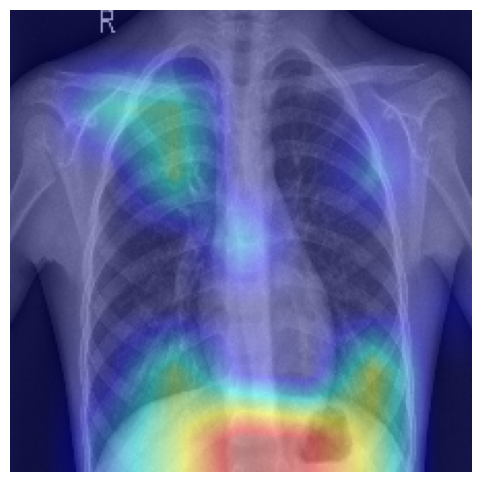

In [88]:
img_path = test_data.filepaths[0]

img = tf.keras.preprocessing.image.load_img(
    img_path, target_size=(IMG_SIZE, IMG_SIZE)
)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

heatmap = grad_cam(model, img_array, last_conv_layer_name="conv5_block3_out")
display_gradcam(img_path, heatmap)

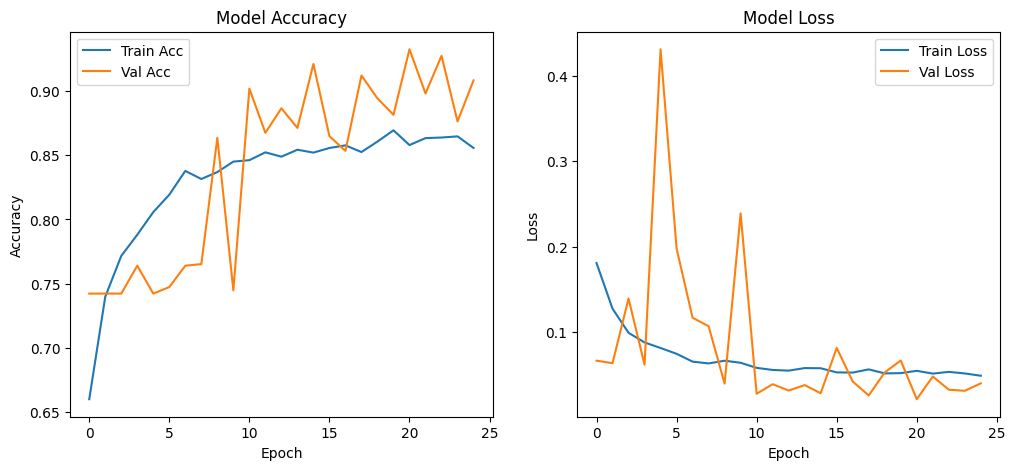

In [89]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

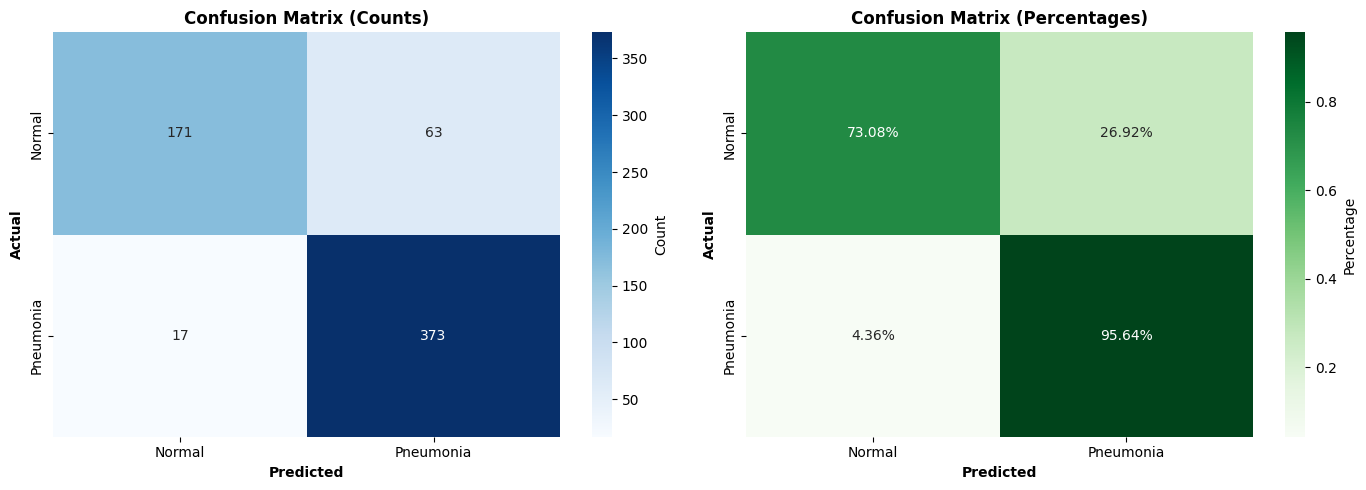


Confusion Matrix Breakdown:
  True Negatives (TN):   171 - Correctly identified normal X-rays
  False Positives (FP):   63 - Normal wrongly flagged as pneumonia
  False Negatives (FN):   17 - Pneumonia missed (CRITICAL)
  True Positives (TP):   373 - Correctly identified pneumonia


In [90]:
cm = confusion_matrix(test_data.classes, pred_labels)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax1,
            xticklabels=["Normal", "Pneumonia"],
            yticklabels=["Normal", "Pneumonia"],
            cbar_kws={'label': 'Count'})
ax1.set_xlabel("Predicted", fontweight='bold')
ax1.set_ylabel("Actual", fontweight='bold')
ax1.set_title("Confusion Matrix (Counts)", fontweight='bold')

sns.heatmap(cm_normalized, annot=True, fmt=".2%", cmap="Greens", ax=ax2,
            xticklabels=["Normal", "Pneumonia"],
            yticklabels=["Normal", "Pneumonia"],
            cbar_kws={'label': 'Percentage'})
ax2.set_xlabel("Predicted", fontweight='bold')
ax2.set_ylabel("Actual", fontweight='bold')
ax2.set_title("Confusion Matrix (Percentages)", fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\nConfusion Matrix Breakdown:")
print(f"  True Negatives (TN):  {cm[0,0]:4d} - Correctly identified normal X-rays")
print(f"  False Positives (FP): {cm[0,1]:4d} - Normal wrongly flagged as pneumonia")
print(f"  False Negatives (FN): {cm[1,0]:4d} - Pneumonia missed (CRITICAL)")
print(f"  True Positives (TP):  {cm[1,1]:4d} - Correctly identified pneumonia")

In [91]:
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)   
specificity = tn / (tn + fp)  
ppv = tp / (tp + fp)          
npv = tn / (tn + fn)      
fpr = fp / (fp + tn)        
fnr = fn / (fn + tp)          

print("="*60)
print("CLINICAL METRICS FOR HOSPITAL DEPLOYMENT")
print("="*60)
print(f"Sensitivity (Recall):      {sensitivity:.4f}  ← Can we detect pneumonia?")
print(f"Specificity:               {specificity:.4f}  ← Can we identify normal?")
print(f"PPV (Precision):           {ppv:.4f}  ← If positive, how likely pneumonia?")
print(f"NPV:                       {npv:.4f}  ← If negative, how likely normal?")
print(f"False Positive Rate:       {fpr:.4f}  ← Unnecessary treatments")
print(f"False Negative Rate:       {fnr:.4f}  ← Missed diagnoses (CRITICAL)")
print("="*60)

print("\nClinical Interpretation:")
if sensitivity >= 0.95:
    print("✓ EXCELLENT sensitivity - Very few pneumonia cases missed")
elif sensitivity >= 0.90:
    print("✓ GOOD sensitivity - Acceptable for screening")
else:
    print("⚠ LOW sensitivity - Too many pneumonia cases missed for clinical use")

if specificity >= 0.90:
    print("✓ EXCELLENT specificity - Few false alarms")
elif specificity >= 0.80:
    print("✓ ACCEPTABLE specificity")
else:
    print("⚠ LOW specificity - Many false positives (unnecessary antibiotics)")

if fnr > 0.10:
    print(f"⚠ WARNING: {fnr*100:.1f}% false negative rate - {fn} pneumonia cases missed!")
    print("  Consider lowering threshold to increase sensitivity")

CLINICAL METRICS FOR HOSPITAL DEPLOYMENT
Sensitivity (Recall):      0.9564  ← Can we detect pneumonia?
Specificity:               0.7308  ← Can we identify normal?
PPV (Precision):           0.8555  ← If positive, how likely pneumonia?
NPV:                       0.9096  ← If negative, how likely normal?
False Positive Rate:       0.2692  ← Unnecessary treatments
False Negative Rate:       0.0436  ← Missed diagnoses (CRITICAL)

Clinical Interpretation:
✓ EXCELLENT sensitivity - Very few pneumonia cases missed
⚠ LOW specificity - Many false positives (unnecessary antibiotics)


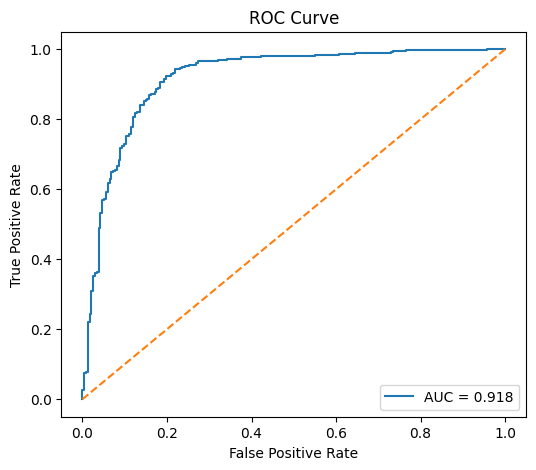

In [92]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(test_data.classes, preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Correct Prediction


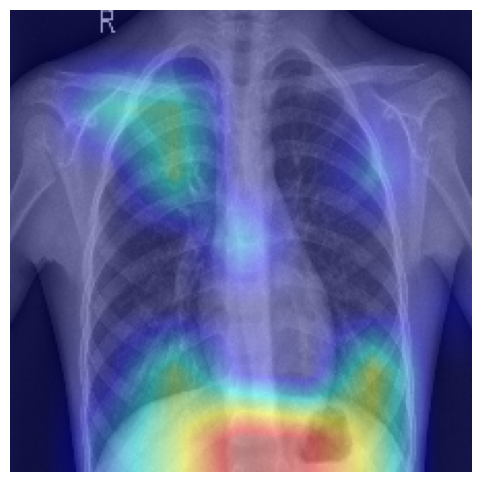

Incorrect Prediction


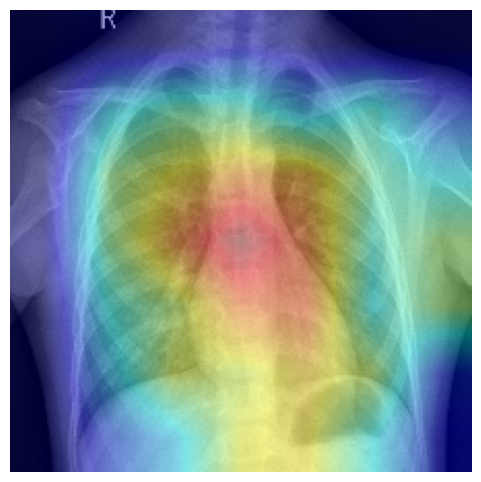

In [93]:
correct_idx = np.where(test_data.classes == pred_labels)[0][0]
wrong_idx = np.where(test_data.classes != pred_labels)[0][0]

def run_gradcam_by_index(index):
    img_path = test_data.filepaths[index]
    
    img = tf.keras.preprocessing.image.load_img(
        img_path, target_size=(IMG_SIZE, IMG_SIZE)
    )
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    heatmap = grad_cam(model, img_array, "conv5_block3_out")
    display_gradcam(img_path, heatmap)

print("Correct Prediction")
run_gradcam_by_index(correct_idx)

print("Incorrect Prediction")
run_gradcam_by_index(wrong_idx)

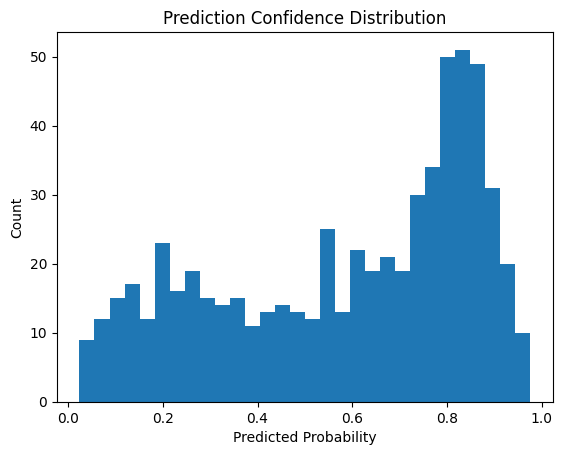

In [94]:
plt.hist(preds, bins=30)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()

In [95]:
print("\n" + "="*60)
print("STARTING FINE-TUNING PHASE")
print("="*60)

for layer in base_model.layers[-30:]:
    layer.trainable = True

print(f"Trainable layers: {sum([l.trainable for l in model.layers])}")
print(f"Total parameters: {model.count_params():,}")
print(f"Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

model.compile(
    optimizer=Adam(1e-5),  
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

ft_checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(MODEL_DIR, 'finetuned_model.keras'),
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

ft_early_stop_cb = EarlyStopping(
    monitor='val_auc',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

ft_reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

ft_callbacks = [ft_checkpoint_cb, ft_early_stop_cb, ft_reduce_lr_cb]

history_ft = model.fit(
    train_data,
    validation_data=val_data,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=ft_callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print("\n" + "="*60)
print("Fine-tuning completed!")
print("="*60)

model = tf.keras.models.load_model(os.path.join(MODEL_DIR, 'finetuned_model.keras'))
print("✓ Best fine-tuned model loaded")


STARTING FINE-TUNING PHASE
Trainable layers: 9
Total parameters: 24,771,457
Trainable parameters: 1,182,209
Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.8630 - auc: 0.9152 - loss: 0.4060 - precision: 0.9037 - recall: 0.9143
Epoch 1: val_auc improved from -inf to 0.97116, saving model to /kaggle/working/models/finetuned_model.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 112s 710ms/step - accuracy: 0.8631 - auc: 0.9153 - loss: 0.4059 - precision: 0.9037 - recall: 0.9142 - val_accuracy: 0.4171 - val_auc: 0.9712 - val_loss: 1.0438 - val_precision: 1.0000 - val_recall: 0.2148 - learning_rate: 1.0000e-05
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.8615 - auc: 0.9260 - loss: 0.3692 - precision: 0.9187 - recall: 0.8907
Epoch 2: val_auc did not improve from 0.97116
139/139 ━━━━━━━━━━━━━━━━━━━━ 87s 623ms/step - accuracy: 0.8616 - auc: 0.9260 - loss: 0.3691 - precision: 0.9188 - recall: 0.8907 - val_accuracy: 0.7423 - val_auc: 0.9702 - val_loss: 0.5857 - val_

In [96]:
print("Evaluating fine-tuned model on test set...")
preds_ft = model.predict(test_data, verbose=1)
pred_labels_ft = (preds_ft > CLINICAL_THRESHOLD).astype(int).flatten()

print("\n" + "="*60)
print("BEFORE vs AFTER FINE-TUNING COMPARISON")
print("="*60)

cm_ft = confusion_matrix(test_data.classes, pred_labels_ft)
tn_ft, fp_ft, fn_ft, tp_ft = cm_ft.ravel()

metrics_comparison = {
    'Initial': {
        'Accuracy': accuracy_score(test_data.classes, pred_labels),
        'Precision': precision_score(test_data.classes, pred_labels),
        'Recall': recall_score(test_data.classes, pred_labels),
        'Specificity': tn / (tn + fp),
        'AUC': roc_auc_score(test_data.classes, preds),
        'F1': f1_score(test_data.classes, pred_labels)
    },
    'Fine-tuned': {
        'Accuracy': accuracy_score(test_data.classes, pred_labels_ft),
        'Precision': precision_score(test_data.classes, pred_labels_ft),
        'Recall': recall_score(test_data.classes, pred_labels_ft),
        'Specificity': tn_ft / (tn_ft + fp_ft),
        'AUC': roc_auc_score(test_data.classes, preds_ft),
        'F1': f1_score(test_data.classes, pred_labels_ft)
    }
}

print(f"{'Metric':<15} {'Initial':<12} {'Fine-tuned':<12} {'Change':<12}")
print("-" * 55)
for metric in metrics_comparison['Initial'].keys():
    initial_val = metrics_comparison['Initial'][metric]
    ft_val = metrics_comparison['Fine-tuned'][metric]
    change = ft_val - initial_val
    change_str = f"+{change:.4f}" if change >= 0 else f"{change:.4f}"
    symbol = "↑" if change > 0.01 else ("↓" if change < -0.01 else "→")
    print(f"{metric:<15} {initial_val:<12.4f} {ft_val:<12.4f} {change_str:<12} {symbol}")

print("-" * 55)

if metrics_comparison['Fine-tuned']['AUC'] > metrics_comparison['Initial']['AUC']:
    print("\n✓ Fine-tuned model shows improvement - USING FINE-TUNED MODEL")
    final_preds = preds_ft
    final_pred_labels = pred_labels_ft
    model.save(os.path.join(MODEL_DIR, 'final_model.keras'))
else:
    print("\n⚠ Initial model performed better - REVERTING TO INITIAL MODEL")
    final_preds = preds
    final_pred_labels = pred_labels
    initial_model = tf.keras.models.load_model(os.path.join(MODEL_DIR, 'best_model.keras'))
    initial_model.save(os.path.join(MODEL_DIR, 'final_model.keras'))

Evaluating fine-tuned model on test set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 422ms/step

BEFORE vs AFTER FINE-TUNING COMPARISON
Metric          Initial      Fine-tuned   Change      
-------------------------------------------------------
Accuracy        0.8718       0.8606       -0.0112      ↓
Precision       0.8555       0.8389       -0.0166      ↓
Recall          0.9564       0.9615       +0.0051      →
Specificity     0.7308       0.6923       -0.0385      ↓
AUC             0.9178       0.9228       +0.0050      →
F1              0.9031       0.8961       -0.0071      →
-------------------------------------------------------

✓ Fine-tuned model shows improvement - USING FINE-TUNED MODEL


In [97]:
import pickle

print("="*60)
print("CREATING DEPLOYMENT PACKAGE")
print("="*60)

metadata = {
    'model_name': 'Pneumonia Detection Model',
    'version': '1.0',
    'date_trained': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'framework': 'TensorFlow/Keras',
    'base_architecture': 'ResNet50',
    'input_size': [IMG_SIZE, IMG_SIZE, 3],
    'output': 'Binary (0=Normal, 1=Pneumonia)',
    'thresholds': {
        'clinical': CLINICAL_THRESHOLD,
        'high_confidence': HIGH_CONFIDENCE_THRESHOLD,
        'low_confidence': LOW_CONFIDENCE_THRESHOLD
    },
    'performance': {
        'test_accuracy': float(accuracy_score(test_data.classes, final_pred_labels)),
        'test_sensitivity': float(recall_score(test_data.classes, final_pred_labels)),
        'test_specificity': float(tn_ft / (tn_ft + fp_ft) if 'tn_ft' in locals() else tn / (tn + fp)),
        'test_auc': float(roc_auc_score(test_data.classes, final_preds)),
        'test_precision': float(precision_score(test_data.classes, final_pred_labels))
    },
    'training_config': {
        'epochs_initial': EPOCHS,
        'epochs_finetuned': FINE_TUNE_EPOCHS,
        'batch_size': BATCH_SIZE,
        'class_weights': class_weight_dict
    },
    'class_distribution': {
        'train': {'normal': int(train_normal), 'pneumonia': int(train_pneumonia)},
        'test': {'normal': int(test_normal), 'pneumonia': int(test_pneumonia)}
    }
}

with open(os.path.join(MODEL_DIR, 'model_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

with open(os.path.join(MODEL_DIR, 'class_indices.json'), 'w') as f:
    json.dump(train_data.class_indices, f, indent=2)

print("✓ Model saved: final_model.keras")
print("✓ Metadata saved: model_metadata.json")
print("✓ Class indices saved: class_indices.json")
print("✓ Training plots saved")

print("\n" + "="*60)
print("DEPLOYMENT CHECKLIST")
print("="*60)
print("✓ Model architecture: ResNet50 transfer learning")
print("✓ Class imbalance: Handled with class weights")
print("✓ Validation strategy: 15% split from training data")
print("✓ Callbacks: ModelCheckpoint, EarlyStopping, ReduceLROnPlateau")
print("✓ Metrics: Accuracy, Precision, Recall, AUC, Specificity, NPV")
print("✓ Clinical thresholds: Configured for triage workflow")
print("✓ Explainability: Grad-CAM implemented")
print("✓ Model versioning: Saved with metadata")

print("\n" + "="*60)
print("NEXT STEPS FOR HOSPITAL DEPLOYMENT")
print("="*60)
print("1. Clinical validation with radiologists")
print("2. Prospective study on new patient data")
print("3. Integration with PACS system")
print("4. Regulatory approval (FDA/CE marking)")
print("5. Monitor performance drift over time")
print("6. Establish human-in-the-loop workflow")
print("7. Create fallback procedures for edge cases")
print("="*60)

print("\nFiles in deployment package:")
for file in os.listdir(MODEL_DIR):
    filepath = os.path.join(MODEL_DIR, file)
    size = os.path.getsize(filepath) / (1024*1024)  # MB
    print(f"  {file:<35} {size:>8.2f} MB")

CREATING DEPLOYMENT PACKAGE
✓ Model saved: final_model.keras
✓ Metadata saved: model_metadata.json
✓ Class indices saved: class_indices.json
✓ Training plots saved

DEPLOYMENT CHECKLIST
✓ Model architecture: ResNet50 transfer learning
✓ Class imbalance: Handled with class weights
✓ Validation strategy: 15% split from training data
✓ Callbacks: ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
✓ Metrics: Accuracy, Precision, Recall, AUC, Specificity, NPV
✓ Clinical thresholds: Configured for triage workflow
✓ Explainability: Grad-CAM implemented
✓ Model versioning: Saved with metadata

NEXT STEPS FOR HOSPITAL DEPLOYMENT
1. Clinical validation with radiologists
2. Prospective study on new patient data
3. Integration with PACS system
4. Regulatory approval (FDA/CE marking)
5. Monitor performance drift over time
6. Establish human-in-the-loop workflow
7. Create fallback procedures for edge cases

Files in deployment package:
  class_indices.json                      0.00 MB
  finetuned_mod

ENSEMBLE PREDICTION WITH TEST-TIME AUGMENTATION
Running 5 prediction passes...
  Pass 1/5: Original data
Found 624 images belonging to 2 classes.
  Pass 2/5: Augmented
Found 624 images belonging to 2 classes.
  Pass 3/5: Augmented
Found 624 images belonging to 2 classes.
  Pass 4/5: Augmented
Found 624 images belonging to 2 classes.
  Pass 5/5: Augmented

ENSEMBLE vs SINGLE MODEL COMPARISON
Metric       Single       Ensemble     Change      
--------------------------------------------------
Accuracy     0.8606       0.8397       -0.0208
Recall       0.9615       0.9667       +0.0051
Precision    0.8389       0.8125       -0.0264

UNCERTAINTY ANALYSIS
High uncertainty cases: 95 (15.2%)
Average uncertainty: 0.0488
Max uncertainty: 0.3267

⚠ High uncertainty cases should be flagged for radiologist review


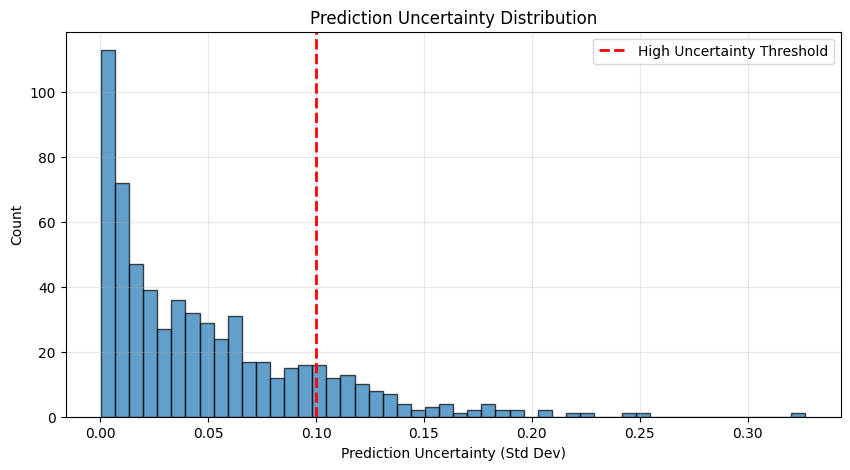


✓ Ensemble predictions completed successfully


In [99]:
def create_ensemble_prediction(model, test_data, n_runs=5):
    """
    Run prediction multiple times with test-time augmentation
    Returns: (ensemble predictions, uncertainty estimates)
    """
    predictions = []
    
    print(f"Running {n_runs} prediction passes...")
    
    for i in range(n_runs):
        if i == 0:
            pred = model.predict(test_data, verbose=0)
            predictions.append(pred)
            print(f"  Pass {i+1}/{n_runs}: Original data")
        else:
            tta_gen = ImageDataGenerator(
                rescale=1./255,
                rotation_range=5,
                width_shift_range=0.05,
                height_shift_range=0.05,
                horizontal_flip=True
            )
            
            tta_data = tta_gen.flow_from_directory(
                TEST_DIR,
                target_size=(IMG_SIZE, IMG_SIZE),
                batch_size=BATCH_SIZE,
                class_mode="binary",
                shuffle=False,
                seed=42+i
            )
            
            pred = model.predict(tta_data, verbose=0)
            predictions.append(pred)
            print(f"  Pass {i+1}/{n_runs}: Augmented")
    
    predictions = np.array(predictions)
    
    ensemble_pred = np.mean(predictions, axis=0)
    
    uncertainty = np.std(predictions, axis=0)
    
    return ensemble_pred, uncertainty

print("="*60)
print("ENSEMBLE PREDICTION WITH TEST-TIME AUGMENTATION")
print("="*60)

try:
    ensemble_preds, pred_uncertainty = create_ensemble_prediction(model, test_data, n_runs=5)
    
    ensemble_labels = (ensemble_preds > CLINICAL_THRESHOLD).astype(int).flatten()
    
    print("\n" + "="*60)
    print("ENSEMBLE vs SINGLE MODEL COMPARISON")
    print("="*60)
    
    single_acc = accuracy_score(test_data.classes, final_pred_labels)
    ensemble_acc = accuracy_score(test_data.classes, ensemble_labels)
    
    single_recall = recall_score(test_data.classes, final_pred_labels)
    ensemble_recall = recall_score(test_data.classes, ensemble_labels)
    
    single_precision = precision_score(test_data.classes, final_pred_labels)
    ensemble_precision = precision_score(test_data.classes, ensemble_labels)
    
    print(f"{'Metric':<12} {'Single':<12} {'Ensemble':<12} {'Change':<12}")
    print("-" * 50)
    print(f"{'Accuracy':<12} {single_acc:<12.4f} {ensemble_acc:<12.4f} {ensemble_acc-single_acc:+.4f}")
    print(f"{'Recall':<12} {single_recall:<12.4f} {ensemble_recall:<12.4f} {ensemble_recall-single_recall:+.4f}")
    print(f"{'Precision':<12} {single_precision:<12.4f} {ensemble_precision:<12.4f} {ensemble_precision-single_precision:+.4f}")
    
    high_uncertainty_idx = np.where(pred_uncertainty.flatten() > 0.10)[0]  # Lowered threshold to 0.10
    print(f"\n{'='*60}")
    print(f"UNCERTAINTY ANALYSIS")
    print(f"{'='*60}")
    print(f"High uncertainty cases: {len(high_uncertainty_idx)} ({len(high_uncertainty_idx)/len(test_data.classes)*100:.1f}%)")
    print(f"Average uncertainty: {np.mean(pred_uncertainty):.4f}")
    print(f"Max uncertainty: {np.max(pred_uncertainty):.4f}")
    print("\n⚠ High uncertainty cases should be flagged for radiologist review")
    
    plt.figure(figsize=(10, 5))
    plt.hist(pred_uncertainty.flatten(), bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(x=0.10, color='red', linestyle='--', linewidth=2, label='High Uncertainty Threshold')
    plt.xlabel('Prediction Uncertainty (Std Dev)')
    plt.ylabel('Count')
    plt.title('Prediction Uncertainty Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(MODEL_DIR, 'uncertainty_distribution.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Ensemble predictions completed successfully")
    
except Exception as e:
    print(f"\n⚠ Ensemble prediction failed: {str(e)}")
    print("Continuing with single model predictions...")
    ensemble_preds = final_preds
    ensemble_labels = final_pred_labels
    pred_uncertainty = np.zeros_like(final_preds)